# ✈️ Flight Price Prediction
## Notebook 3: Baseline Model

**Цель:** Обучить baseline модель без feature engineering, зафиксировать начальную метрику.

**Baseline** — простая Linear Regression «из коробки». Это точка отсчёта — любая следующая модель должна быть лучше.

**Метрики:**
- **RMSE** (Root Mean Squared Error) — основная. Штрафует за большие ошибки, единицы — те же что у цены (рупии)
- **MAE** (Mean Absolute Error) — дополнительная. Средняя абсолютная ошибка, более устойчива к выбросам
- **R²** (коэффициент детерминации) — какую долю дисперсии объясняет модель (1.0 = идеал)

## 0. Импорты

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

print('Импорты выполнены ✅')

Импорты выполнены ✅


## 1. Загрузка обработанных данных

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val   = pd.read_csv('../data/processed/X_val.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/processed/y_val.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

with open('../data/processed/features.json') as f:
    meta = json.load(f)
FEATURES = meta['features']

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (206290, 16), Val: (44205, 16), Test: (44206, 16)


## 2. Вспомогательная функция оценки

In [3]:
def evaluate(model, X, y, split_name='Val'):
    """Вычисляет и выводит метрики модели."""
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae  = mean_absolute_error(y, y_pred)
    r2   = r2_score(y, y_pred)
    print(f'  [{split_name}] RMSE: {rmse:>10,.0f} | MAE: {mae:>10,.0f} | R²: {r2:.4f}')
    return {'split': split_name, 'rmse': rmse, 'mae': mae, 'r2': r2}

# Таблица экспериментов
experiments = []

## 3. DummyRegressor — нулевой baseline

Просто предсказывает среднее по train. Самая наивная модель — нижняя планка.

In [4]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)

print('=== DummyRegressor (predict mean) ===')
res_train = evaluate(dummy, X_train, y_train, 'Train')
res_val   = evaluate(dummy, X_val,   y_val,   'Val')

experiments.append({
    'model': 'DummyRegressor (mean)',
    'features': 'все признаки',
    'notes': 'наивный baseline',
    **{f'train_{k}': v for k, v in res_train.items() if k != 'split'},
    **{f'val_{k}': v for k, v in res_val.items() if k != 'split'},
})

=== DummyRegressor (predict mean) ===
  [Train] RMSE:     21,885 | MAE:     19,101 | R²: 0.0000
  [Val] RMSE:     21,927 | MAE:     19,132 | R²: -0.0000


## 4. Linear Regression — основной baseline (без FE)

**Важно:** Берём только исходные признаки из датасета, без наших новых фич.

In [5]:
# Только базовые признаки — без инженерных
BASE_FEATURES = [
    'duration',
    'days_left',
    'stops_encoded',
    'departure_time_encoded',
    'arrival_time_encoded',
    'airline_encoded',
    'source_city_encoded',
    'destination_city_encoded',
    'class_encoded',
]

# LinearRegression чувствительна к масштабу
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[BASE_FEATURES])
X_val_scaled   = scaler.transform(X_val[BASE_FEATURES])

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

print('=== Linear Regression (базовые признаки, без FE) ===')
res_train = evaluate(lr, X_train_scaled, y_train, 'Train')
res_val   = evaluate(lr, X_val_scaled,   y_val,   'Val')

experiments.append({
    'model': 'Linear Regression',
    'features': 'базовые (без FE)',
    'notes': 'baseline CP1',
    **{f'train_{k}': v for k, v in res_train.items() if k != 'split'},
    **{f'val_{k}': v for k, v in res_val.items() if k != 'split'},
})

=== Linear Regression (базовые признаки, без FE) ===
  [Train] RMSE:      6,336 | MAE:      4,279 | R²: 0.9162
  [Val] RMSE:      6,319 | MAE:      4,276 | R²: 0.9169


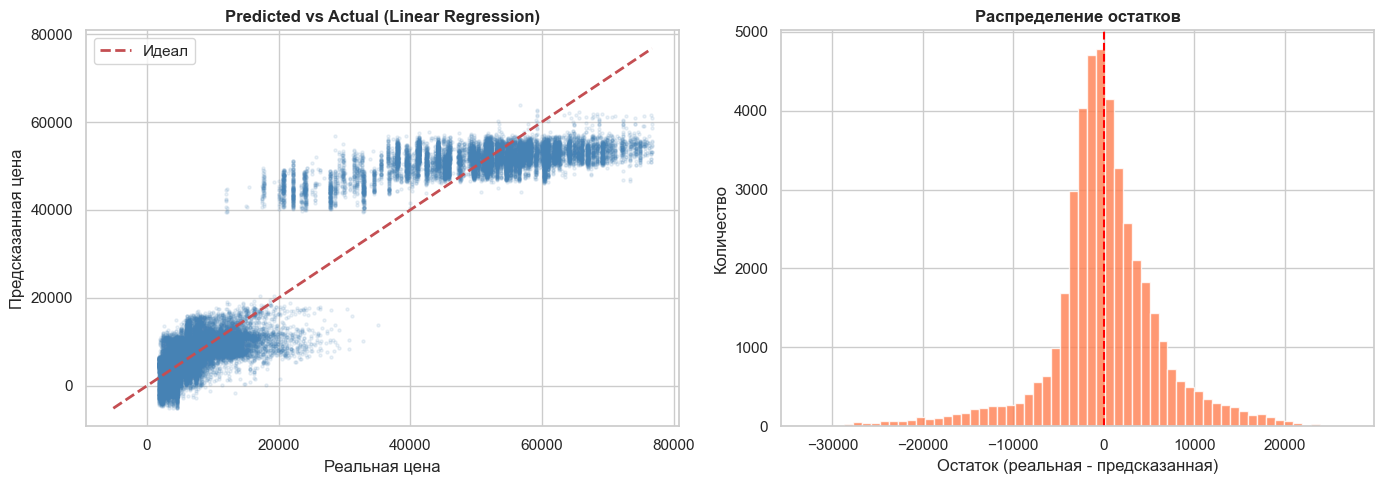

In [6]:
# Визуализация: предсказания vs реальные значения
y_pred_val = lr.predict(X_val_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
axes[0].scatter(y_val, y_pred_val, alpha=0.1, s=5, color='steelblue')
lims = [min(y_val.min(), y_pred_val.min()), max(y_val.max(), y_pred_val.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Идеал')
axes[0].set_title('Predicted vs Actual (Linear Regression)', fontweight='bold')
axes[0].set_xlabel('Реальная цена')
axes[0].set_ylabel('Предсказанная цена')
axes[0].legend()

# Распределение остатков
residuals = y_val - y_pred_val
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Распределение остатков', fontweight='bold')
axes[1].set_xlabel('Остаток (реальная - предсказанная)')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.savefig('../data/plots/baseline_residuals.png', bbox_inches='tight')
plt.show()

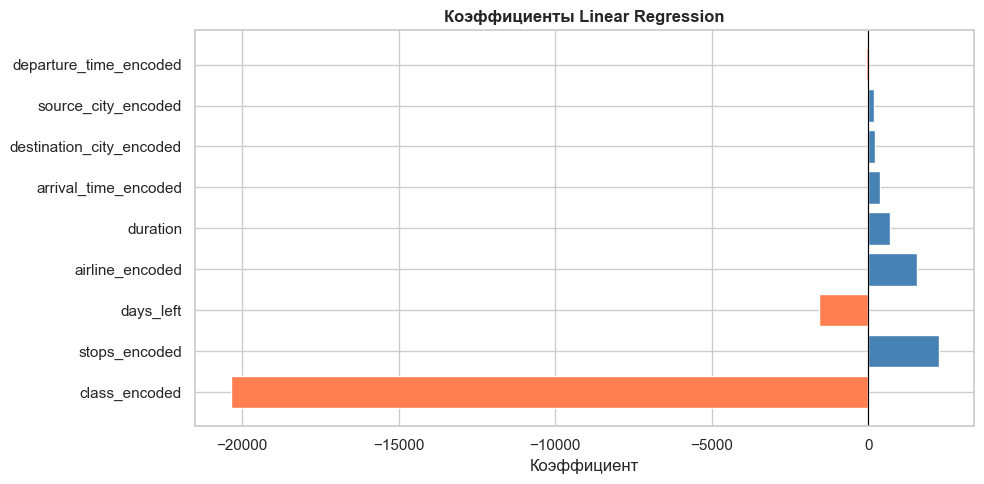

In [7]:
# Коэффициенты модели
coef_df = pd.DataFrame({
    'feature': BASE_FEATURES,
    'coefficient': lr.coef_
}).sort_values('coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Коэффициенты Linear Regression', fontweight='bold')
plt.xlabel('Коэффициент')
plt.tight_layout()
plt.savefig('../data/plots/lr_coefficients.png', bbox_inches='tight')
plt.show()

## 5. Таблица экспериментов (CP1)

In [8]:
exp_df = pd.DataFrame(experiments)

# Форматирование для удобства
display_cols = ['model', 'features', 'notes', 'val_rmse', 'val_mae', 'val_r2']
exp_display = exp_df[display_cols].copy()
exp_display['val_rmse'] = exp_display['val_rmse'].apply(lambda x: f'{x:,.0f}')
exp_display['val_mae']  = exp_display['val_mae'].apply(lambda x: f'{x:,.0f}')
exp_display['val_r2']   = exp_display['val_r2'].apply(lambda x: f'{x:.4f}')
exp_display.columns = ['Модель', 'Признаки', 'Заметки', 'RMSE (val)', 'MAE (val)', 'R² (val)']

print('=== Таблица экспериментов CP1 ===')
print(exp_display.to_string(index=False))

# Сохраняем
exp_df.to_csv('../data/processed/experiments_cp1.csv', index=False)
print('\nТаблица сохранена в data/processed/experiments_cp1.csv ✅')

=== Таблица экспериментов CP1 ===
               Модель         Признаки          Заметки RMSE (val) MAE (val) R² (val)
DummyRegressor (mean)     все признаки наивный baseline     21,927    19,132  -0.0000
    Linear Regression базовые (без FE)     baseline CP1      6,319     4,276   0.9169

Таблица сохранена в data/processed/experiments_cp1.csv ✅


## 6. Выводы CP1

- **DummyRegressor** предсказывает среднее — R² ≈ 0, RMSE максимальный. Это нижняя планка.
- **Linear Regression** уже значительно лучше, но линейная модель не может уловить нелинейные зависимости (например, влияние класса Business).
- **В CP2** будем добавлять: RandomForest, XGBoost/LightGBM, ансамбли, подбор гиперпараметров.
- **Гипотезы для CP2:**
  1. Feature Engineering (новые признаки) улучшит качество.
  2. Логарифм таргета поможет линейной модели.
  3. Бустинг (XGBoost) превзойдёт линейную модель за счёт нелинейности.